# Disneyland Reviews — Exploratory Data Analysis

**Team 4 — Sentiment Analysis (NLP).** Machine Learning 2026-III, Universidad Distrital
Francisco José de Caldas.

Workshop #0/#1 deliverable: understand the corpus before any model is trained. Every
number below is computed from the data, and every cleaning decision is *proposed*, not
applied — dropping rows here would leak exploratory decisions into the test set.

## Three limits of this corpus, established up front

The assignment template asks for analyses this dataset cannot support. Rather than
silently skipping them:

| Requested | Status |
| --- | --- |
| Per-user analysis, group split by user | **Not possible.** There is no user column. `Review_ID` is unique per review (42,636 distinct in 42,656 rows), not per person. |
| Day-of-week analysis | **Not possible.** `Year_Month` has month granularity (`"2019-4"`). Temporal analysis stops at the month. |
| Multilingual handling | **Not needed.** A 3,000-review sample detected 100% English. |

## 1. Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ml_npl.dataset import load_reviews
from ml_npl import eda, plots

plots.apply_theme()
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

RANDOM_STATE = 42  # fixed so every run of this notebook is reproducible

/home/juliancelis/.cache/pypoetry/virtualenvs/ml-npl-IPkIm5Ic-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 02. Data Loading

The loader downloads from Kaggle on first run and reads from a local cache afterwards.

In [ ]:
raw = load_reviews()          # never mutated: every later step works on a copy
print(f"{len(raw):,} reviews x {raw.shape[1]} columns")
raw.head(3)

42,656 reviews x 6 columns


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong ...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,"Its been a while since d last time we visit HK Disneyland .. Yet, this time ...",Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid when I was visiting the park o...,Disneyland_HongKong


## 3. Initial Inspection

Which column can play which role. Nothing is assumed — the `role` column records what
each field actually contains.

In [ ]:
eda.column_inventory(raw)

,column,dtype,unique,nulls,pct_null,constant,unique_key,role
0,Review_ID,int64,42636,0,0.0,False,False,"identifier (per review, NOT per user)"
1,Rating,int64,5,0,0.0,False,False,ordinal 1-5 score; source of the sentiment target
2,Year_Month,str,112,0,0.0,False,False,"visit period as 'YYYY-M'; month granularity, no day"
3,Reviewer_Location,str,162,0,0.0,False,False,reviewer's self-declared country
4,Review_Text,str,42632,0,0.0,False,False,free-text review body; the only model input
5,Branch,str,3,0,0.0,False,False,which Disneyland park the review is about


In [4]:
print("--- numeric ---")
display(raw.describe(include="number").round(3))
print("--- categorical ---")
display(raw.describe(include=["object", "string"]).drop(columns=["Review_Text"]))

--- numeric ---


,Review_ID,Rating
count,4.265600e+04,42656.000
mean,3.188553e+08,4.218
std,1.657092e+08,1.063
min,1.398724e+06,1.000
25%,1.743274e+08,4.000
50%,2.907583e+08,5.000
75%,4.489579e+08,5.000
max,6.708014e+08,5.000


--- categorical ---


,Year_Month,Reviewer_Location,Branch
count,42656,42656,42656
unique,112,162,3
top,missing,United States,Disneyland_California
freq,2613,14551,19406


**Reading the inventory.**

* `Review_ID` — 42,636 distinct values in 42,656 rows. Not a unique key, and **not a user
  id**: each value identifies one review.
* `Rating` — five ordered levels. This is the source of the sentiment target.
* `Year_Month` — 112 distinct values, the most frequent being the literal string
  `"missing"`. This is absent data disguised as a category, so `isna()` reports zero.
* `Reviewer_Location` — 162 countries, led by the United States (14,551 reviews).
* `Review_Text` — the only legitimate model input.
* `Branch` — three parks. California alone is 45.5% of the corpus.

No column is constant and none is a unique key.

## 04. Data Quality

Each issue is counted and given a suggested treatment. **Nothing is dropped here.** Any
removal has to happen after the train/test split, or the decision leaks.

In [5]:
quality = eda.quality_report(raw)
quality

,issue,count,pct,suggested_treatment
0,null values (any column),0,0.00,none present; nothing to impute
1,fully duplicated rows,12,0.03,"drop: identical in every column, pure redundancy"
2,duplicated Review_ID,20,0.05,inspect: the id is meant to be unique
3,duplicated Review_Text,24,0.06,drop before splitting: same text on both sides inflates test scores
4,empty or whitespace-only reviews,0,0.00,drop: no signal for a text model
5,reviews under 3 words,0,0.00,"keep but flag: short reviews are legitimate, just low-information"
6,reviews over 1000 words,172,0.40,"keep: genuine long reviews; truncate at model level, not here"
7,symbols/digits only,0,0.00,drop: carries no lexical content
8,contains a URL,59,0.14,"strip the URL, keep the review"
9,contains emoji,0,0.00,keep: emoji carry sentiment; strip only for bag-of-words models


**What is a real defect vs. a natural feature of the corpus:**

*Defects worth acting on*
* **12 fully duplicated rows** (0.03%) — identical in every column.
* **24 duplicated review texts** (0.06%) — the leakage vector. If the same text lands in
  both train and test, the reported score is inflated. 23 of the 24 duplicate groups carry
  the *same* rating; one group disagrees with itself, which is a labelling conflict.
* **20 duplicated `Review_ID`s** — the id is supposed to be unique and is not.
* **2,613 `"missing"` sentinels** (6.13%) in `Year_Month` — should become `NaT` so that
  missingness is visible to `isna()`.

*Natural characteristics, not defects*
* **172 reviews over 1,000 words** (0.40%) — genuine long reviews. Truncation belongs to
  the model's tokenizer, not to the dataset.
* **59 reviews containing a URL** (0.14%) — strip the URL, keep the review.
* **0 empty, 0 symbol-only, 0 out-of-range ratings, 0 emoji.** The corpus is clean on
  these axes.

## 05. Target Analysis

`Rating` is ordinal on 1-5. The question is whether — and how — it becomes a sentiment
label.

In [6]:
rating = raw["Rating"]
print(f"mean {rating.mean():.3f} | median {rating.median():.0f} | mode {rating.mode()[0]} "
      f"| std {rating.std():.3f}")
print(f"Q1 {rating.quantile(.25):.0f} | Q3 {rating.quantile(.75):.0f}")

distribution = pd.DataFrame({"count": rating.value_counts().sort_index()})
distribution["pct"] = (distribution["count"] / len(rating) * 100).round(2)
distribution

mean 4.218 | median 5 | mode 5 | std 1.063
Q1 4 | Q3 5


,count,pct
Rating,,
1,1499,3.51
2,2127,4.99
3,5109,11.98
4,10775,25.26
5,23146,54.26


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


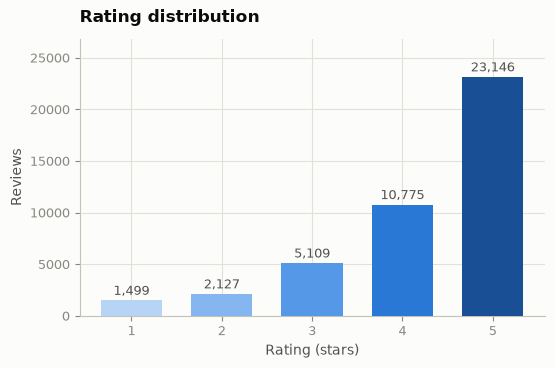

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.6))
plots.rating_distribution(raw, ax=ax)
plt.show()

The distribution is strongly left-skewed: **54.3% of reviews are 5 stars** and the median
*is* the maximum. An IQR outlier rule does not apply to a five-level ordinal variable, so
no rating is an "outlier" — the skew is the shape of the data, not an error.

### Choosing a label scheme

The 1-2 / 3 / 4-5 split is the usual default, but it should be argued rather than assumed.
Both candidates, measured:

In [8]:
for scheme in ("three_class", "binary"):
    labels = eda.sentiment_from_rating(rating, scheme)
    print(f"--- {scheme} ---")
    display(eda.class_balance(labels))

--- three_class ---


,count,pct,ratio_vs_smallest
Rating,,,
positive,33921,79.52,9.4
neutral,5109,11.98,1.4
negative,3626,8.50,1.0


--- binary ---


,count,pct,ratio_vs_smallest
Rating,,,
positive,33921,79.52,3.9
negative,8735,20.48,1.0


**Three-class** (1-2 neg / 3 neu / 4-5 pos): positive 79.5%, neutral 12.0%, negative 8.5%.
Imbalance **9.4:1**.

**Binary** (1-3 neg / 4-5 pos): positive 79.5%, negative 20.5%. Imbalance **3.9:1**.

Neither is obviously right:

* The three-class scheme keeps the neutral band, which is the linguistically interesting
  case — but 3-star reviews are the hardest to separate and the class is small.
* The binary scheme folds 3 stars into "negative", which is a **substantive claim**: a
  3-star review is mixed, not negative. It buys a far gentler imbalance at the cost of
  label fidelity.

A third option is to **drop 3-star reviews** and train a clean binary task on 37,547
reviews (positive 90.3% / negative 9.7%) — cleaner labels, worse imbalance, and a model
that cannot handle the neutral case at inference.

**Recommendation:** carry the three-class scheme as primary, because it matches the data
and is the harder, more honest task; report binary as a secondary framing for comparison
with published baselines. Whichever is chosen must be fixed *before* modelling and kept
constant across all six workshops, or the metrics stop being comparable.

**Is there enough data?** Yes for classical ML (the smallest class, negative, has 3,626
examples). For a transformer fine-tune, 3,626 minority examples is workable. For training
an RNN from scratch on the minority class alone it is thin — class weighting or
resampling will matter more than architecture.

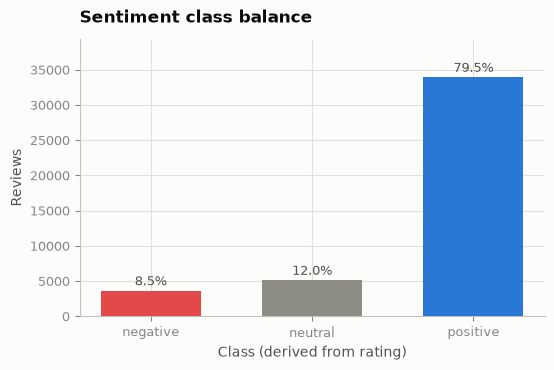

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.6))
plots.sentiment_distribution(eda.sentiment_from_rating(rating, "three_class"), ax=ax)
plt.show()

## 06. Text Analysis

Derived metrics are **added as new columns**; `Review_Text` is never overwritten, because
the transformer workshops need the raw string.

In [10]:
df = eda.add_text_features(raw)
df["sentiment"] = eda.sentiment_from_rating(df["Rating"], "three_class")
df["period"] = eda.parse_period(df["Year_Month"])

metrics = ["n_chars", "n_words", "n_sentences", "n_unique_words", "unique_ratio",
           "mean_word_len", "caps_ratio", "n_exclaim"]
df[metrics].describe().round(3)

,n_chars,n_words,n_sentences,n_unique_words,unique_ratio,mean_word_len,caps_ratio,n_exclaim
count,42656.000,42656.000,42656.000,42656.000,42656.000,42656.000,42656.000,42656.000
mean,696.818,129.704,7.126,80.320,0.740,5.399,0.027,1.245
std,831.397,154.713,7.732,66.468,0.128,0.543,0.016,2.742
min,18.000,3.000,1.000,3.000,0.079,3.520,0.000,0.000
25%,239.000,45.000,3.000,36.000,0.652,5.160,0.018,0.000
50%,435.000,81.000,5.000,60.000,0.746,5.360,0.024,0.000
75%,837.000,156.000,9.000,102.000,0.833,5.590,0.033,2.000
max,20756.000,3963.000,244.000,1011.000,1.000,61.200,0.500,136.000


Note the two tokenizations in `eda.add_text_features`, kept deliberately separate:
`n_words` counts whitespace tokens (what a reader perceives as length) while `n_tokens`
counts alphabetic tokens (vocabulary). `unique_ratio` divides unique by `n_tokens`, so it
is a proper type/token ratio bounded by 1. Mixing the two makes the ratio exceed 1 —
`"well-organized,fun"` is one whitespace token but three words.

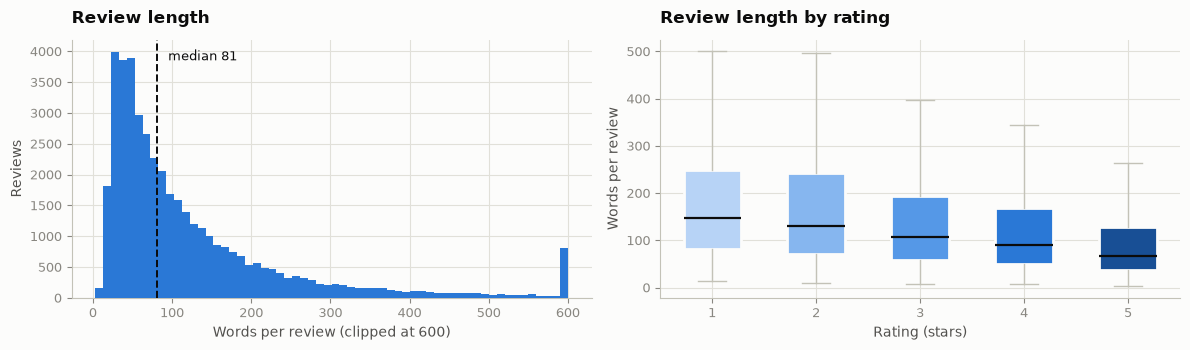

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
plots.length_distribution(df, ax=axes[0])
plots.length_by_rating(df, ax=axes[1])
plt.tight_layout(); plt.show()

In [12]:
# Patterns that sometimes indicate spam or shouting. Counted, not removed.
flags = {
    "caps_ratio > 0.30": (df["caps_ratio"] > 0.30).sum(),
    "more than 10 '!'": (df["n_exclaim"] > 10).sum(),
    "unique_ratio < 0.30 (repetitive)": (df["unique_ratio"] < 0.30).sum(),
    "contains a URL": df["has_url"].sum(),
    "contains an emoji": df["has_emoji"].sum(),
}
pd.Series(flags, name="reviews").to_frame()

,reviews
caps_ratio > 0.30,8
more than 10 '!',583
unique_ratio < 0.30 (repetitive),9
contains a URL,59
contains an emoji,0


Volumes are tiny: 8 shouted reviews, 10 highly repetitive ones, 59 with URLs, no emoji at
all. **There is no spam problem in this corpus** — worth stating explicitly, because the
usual review-dataset cleaning playbook would waste effort here.

## 07. Linguistic Analysis

The original text is preserved; normalisation happens on a copy.

In [13]:
# A normalised view for frequency counting. `Review_Text` stays untouched.
normalised = (
    df["Review_Text"].str.lower()
    .str.replace(r"https?://\S+", " ", regex=True)
    .str.replace(r"[^a-z\s']", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
print("original  :", df["Review_Text"].iloc[0][:110])
print("normalised:", normalised.iloc[0][:110])

vocabulary = set()
normalised.str.split().map(vocabulary.update)
print(f"\ntotal tokens: {df['n_tokens'].sum():,} | vocabulary: {len(vocabulary):,} types")

original  : If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when yo
normalised: if you've ever been to disneyland anywhere you'll find disneyland hong kong very similar in the layout when yo



total tokens: 5,489,960 | vocabulary: 42,423 types


### Which transformations suit which model

| Step | Classical (NB / LogReg / SVM) | Neural (RNN, LSTM, BERT) |
| --- | --- | --- |
| Lowercasing | **Yes** — halves the vocabulary with no loss for bag-of-words | Optional; BERT has cased variants where case carries signal |
| Punctuation removal | **Yes** — TF-IDF cannot use it | **No** — `!` and `?` carry sentiment; transformers tokenize them |
| Stopword removal | **Usually** — but keep negations | **No** — "not good" collapses to "good" if `not` is stripped |
| Stemming / lemmatisation | **Yes** — merges inflections and shrinks the feature space | **No** — destroys subword structure the tokenizer relies on |
| Truncation | Not applicable | **Yes** — BERT caps at 512 tokens; 0.4% of reviews exceed 1,000 words |

The single most dangerous default is **stopword removal**: NLTK's English list contains
`not`, `no`, `nor` and `don't`. Removing them inverts the meaning of exactly the reviews
sentiment analysis exists to catch. Use a custom list that retains negations.

## 08. Ngrams

Frequencies overall and per sentiment class. Frequency alone does not make a word
positive or negative — the comparison *between* classes is what carries information.

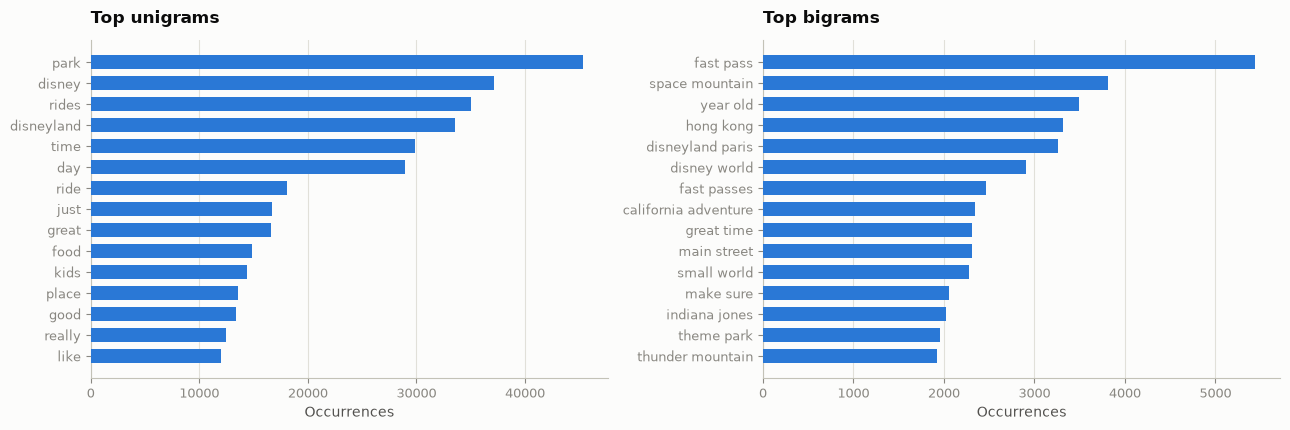

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
plots.top_terms(eda.top_ngrams(df["Review_Text"], (1, 1), 15), "Top unigrams", ax=axes[0])
plots.top_terms(eda.top_ngrams(df["Review_Text"], (2, 2), 15), "Top bigrams", ax=axes[1])
plt.tight_layout(); plt.show()

In [15]:
for label in ["negative", "neutral", "positive"]:
    subset = df.loc[df["sentiment"] == label, "Review_Text"]
    top = eda.top_ngrams(subset, (2, 2), top_n=8)
    print(f"{label:>8} (n={len(subset):,}): " + ", ".join(top["ngram"]))

negative (n=3,626): disneyland paris, fast pass, year old, space mountain, rides closed, disney world, theme park, cast members


 neutral (n=5,109): fast pass, disneyland paris, space mountain, disney world, hong kong, year old, cast members, thunder mountain


positive (n=33,921): fast pass, space mountain, year old, hong kong, disney world, great time, disneyland paris, california adventure


**The top n-grams are almost entirely entity and topic terms, not sentiment terms**:
`fast pass`, `space mountain`, `hong kong`, `main street`. A sentiment model built on raw
frequency would be learning *what the review is about*, not how the writer felt.

Two contrasts do carry signal:

* `rides closed` appears in the negative top-8 and in neither other class.
* `great time` appears only in the positive top-8.

And one is a warning rather than a finding: **`disneyland paris` is the single most
frequent bigram in negative reviews (625) but only seventh in positive ones.** That is
the park's identity leaking into the label — see the bias section.

## 09. Group Analysis — by park

Differences are described, not ranked. This data cannot support a claim about which park
is "better": reviewers self-select, and the three parks draw different populations.

In [16]:
by_branch = df.groupby("Branch").agg(
    reviews=("Rating", "size"),
    mean_rating=("Rating", "mean"),
    median_rating=("Rating", "median"),
    median_words=("n_words", "median"),
).round(3)
by_branch["pct_of_corpus"] = (by_branch["reviews"] / len(df) * 100).round(1)
by_branch

,reviews,mean_rating,median_rating,median_words,pct_of_corpus
Branch,,,,,
Disneyland_California,19406,4.405,5.0,71.0,45.5
Disneyland_HongKong,9620,4.204,4.0,70.0,22.6
Disneyland_Paris,13630,3.960,4.0,112.0,32.0


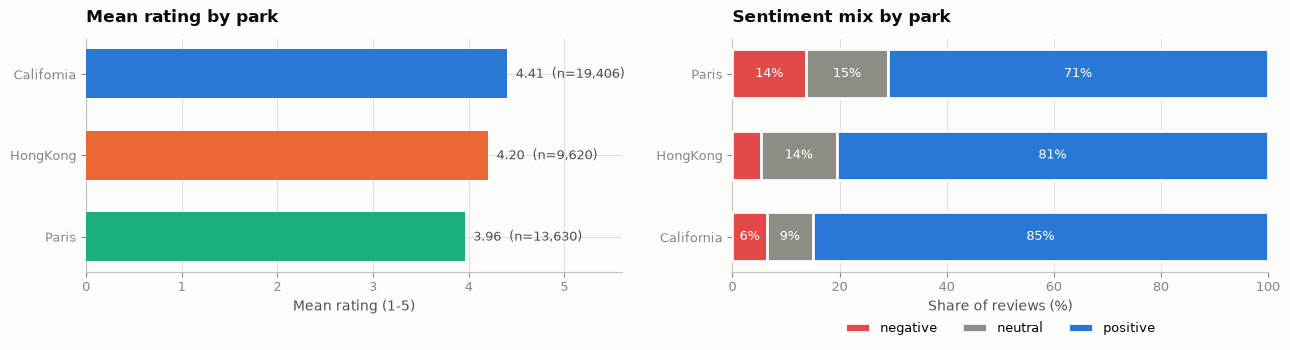

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
plots.mean_rating_by_branch(df, ax=axes[0])
plots.sentiment_by_branch(df, ax=axes[1])
plt.tight_layout(); plt.show()

The parks are represented very unevenly (California 45.5%, Paris 32.0%, Hong Kong 22.6%)
and their sentiment mixes differ sharply: **13.7% of Paris reviews are negative against
6.4% of California's** — more than double. Paris reviews are also markedly longer (median
112 words vs ~70 elsewhere).

Whether that reflects the parks, the reviewers, the period, or the languages spoken
nearby is **not answerable from this data**.

## 10. Temporal Analysis

`Year_Month` gives month granularity. There is no day, so no day-of-week analysis.

In [18]:
valid = df.dropna(subset=["period"])
print(f"parseable periods: {len(valid):,} | NaT (the 'missing' sentinel): {df['period'].isna().sum():,}")
print(f"range: {valid['period'].min()} -> {valid['period'].max()}")

per_year = valid.groupby(valid["period"].dt.year).agg(
    reviews=("Rating", "size"), mean_rating=("Rating", "mean")).round(3)
per_year

parseable periods: 40,043 | NaT (the 'missing' sentinel): 2,613
range: 2010-03 -> 2019-05


,reviews,mean_rating
period,,
2010,143,4.168
2011,1984,4.215
2012,4342,4.289
2013,4717,4.224
2014,5301,4.241
2015,6979,4.259
2016,6599,4.235
2017,5195,4.236
2018,3997,4.137


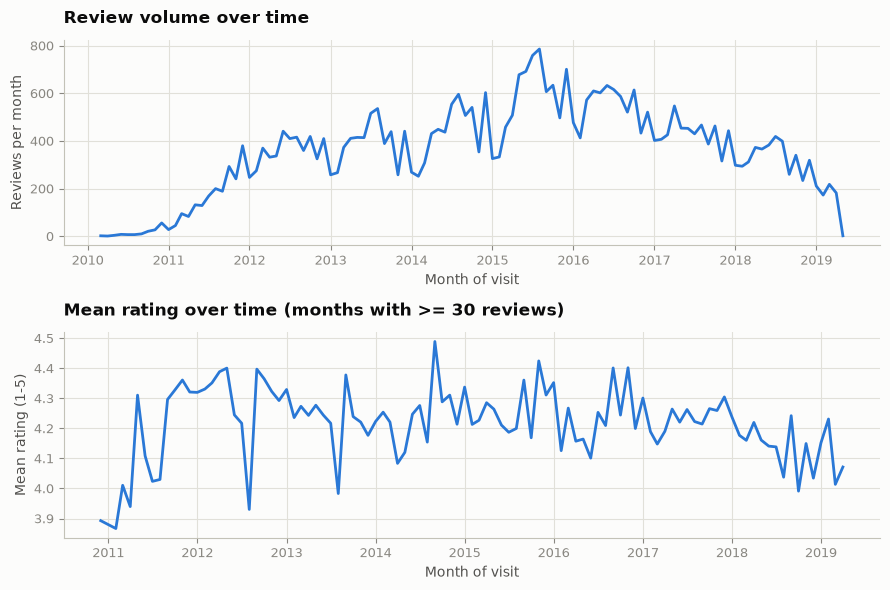

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6))
plots.reviews_over_time(df, ax=axes[0])
plots.rating_over_time(df, ax=axes[1])
plt.tight_layout(); plt.show()

Volume rises to a 2015 peak (6,979 reviews) and falls away; 2010 (143) and 2019 (786) are
partial years and should not be read as trends. Mean rating is remarkably stable around
4.2 across the decade, easing to 4.11 in 2019.

Eleven of 111 months hold fewer than 30 reviews. The rating chart drops them rather than
drawing a noisy average over a handful of observations.

**Two separate charts, deliberately.** Volume and mean rating have different units and
scales; putting them on twin y-axes would invite a causal reading the data does not
support.

## 11. Outlier Analysis

Statistical extremes are separated from data errors.

In [20]:
rows = []
for column in ["n_words", "n_chars", "n_sentences"]:
    q1, q3 = df[column].quantile([0.25, 0.75])
    upper = q3 + 1.5 * (q3 - q1)
    count = int((df[column] > upper).sum())
    rows.append({"metric": column, "iqr_upper_bound": round(upper),
                 "above": count, "pct": round(count / len(df) * 100, 2),
                 "max": df[column].max()})
pd.DataFrame(rows)

,metric,iqr_upper_bound,above,pct,max
0,n_words,322,3220,7.55,3963
1,n_chars,1734,3221,7.55,20756
2,n_sentences,18,2518,5.90,244


About 7.5% of reviews sit above the IQR fence on length. **These are not errors.** A
3,963-word review is a real person writing at length about a theme park; the longest
reviews read as detailed trip reports, and length is itself correlated with rating.

Removing them would delete exactly the reviews that carry the most negative signal — the
very cases the model most needs. The right treatment is truncation at the model's input
limit, applied inside the modelling pipeline, not deletion from the dataset.

`Rating` has no outliers to speak of: it is a five-level ordinal scale, so the IQR rule is
not meaningful.

## 12. Data Leakage

**Mandatory section.** What may be a feature, what may only build the target, and what
must be excluded entirely.

In [21]:
temporal_index = valid["period"].dt.year * 12 + valid["period"].dt.month
checks = {
    "Review_ID vs time (is the id a timestamp?)":
        valid["Review_ID"].corr(temporal_index, method="spearman"),
    "Review_ID vs Rating":
        df["Review_ID"].corr(df["Rating"], method="spearman"),
    "n_words vs Rating (shortcut feature)":
        df["n_words"].corr(df["Rating"], method="spearman"),
    "n_chars vs n_words (redundancy)":
        df["n_chars"].corr(df["n_words"], method="spearman"),
}
pd.Series(checks, name="spearman_rho").round(4).to_frame()

,spearman_rho
Review_ID vs time (is the id a timestamp?),0.9927
Review_ID vs Rating,0.0098
n_words vs Rating (shortcut feature),-0.2264
n_chars vs n_words (redundancy),0.9967


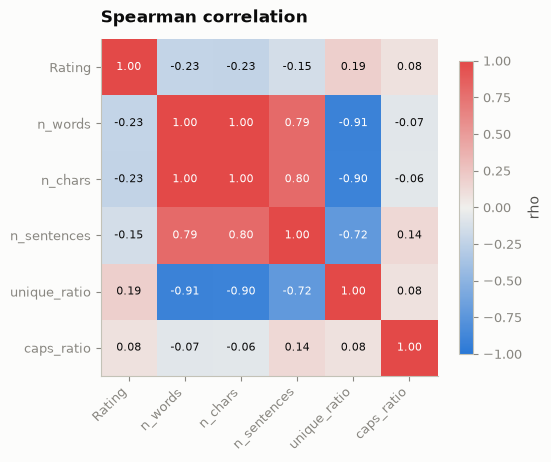

In [22]:
fig, ax = plt.subplots(figsize=(5.6, 4.8))
plots.correlation_matrix(
    df, ["Rating", "n_words", "n_chars", "n_sentences", "unique_ratio", "caps_ratio"], ax=ax)
plt.tight_layout(); plt.show()

### Verdicts

| Variable | Verdict | Why |
| --- | --- | --- |
| `Review_Text` | **Feature** | The only legitimate input for a sentiment model. |
| `Rating` | **Target only — never a feature** | The label is derived from it. Including it gives the model the answer; accuracy would approach 100% and mean nothing. |
| `sentiment` | **Target** | A deterministic function of `Rating`. |
| `Review_ID` | **Exclude** | Spearman **+0.9927** against the visit month: the id is effectively a timestamp. As a feature it leaks temporal position; worse, it lets a tree model memorise the training rows. |
| `Year_Month` | **Exclude from features** | Fine for analysis and for a temporal split, but as a feature it invites learning period-specific artefacts. |
| `Branch` | **Exclude, or use with care** | Negative rates run 6.4% (California) to 13.7% (Paris). A model given `Branch` can predict sentiment from the park alone. |
| `Reviewer_Location` | **Exclude** | 162 levels, heavily skewed to the US; a high-cardinality proxy with the same risk. |
| `n_words`, `n_chars`, … | **Derived — use knowingly** | Not leakage (they come from the text), but `n_words` correlates -0.23 with rating: a shortcut that predicts sentiment from length rather than meaning. |

### That `Review_ID` correlation cuts both ways

`rho = +0.9927` is a warning as a feature — and an opportunity elsewhere. The 2,613 rows
whose period is `"missing"` can still be **ordered in time** by their id. If a temporal
split is chosen, those rows need not be discarded.

### Feature redundancy

`n_words` and `n_chars` correlate at **1.00**: they are the same feature twice. Keeping
both adds nothing and destabilises the coefficients of linear models. `unique_ratio`
correlates -0.91 with `n_words`, which is close to mechanical — long reviews repeat words.
Pick one length feature.

## 13. Visualizations

The figures live beside the sections they support rather than in a gallery at the end.
Colour is assigned by the job it does: a **sequential** blue ramp for the ordered rating,
a **diverging** red/grey/blue scale for sentiment polarity and for correlations, and
**categorical** hues for the three parks. The categorical trio was validated for
colour-vision deficiency (worst pair ΔE 9.2) and every low-contrast fill carries a direct
value label.

## 14. Preprocessing Recommendations

### Keep untouched
`Review_ID`, `Rating`, `Year_Month`, `Reviewer_Location`, `Review_Text`, `Branch`.

### Derive (additive columns only)
`text_normalised`, `n_words`, `n_sentences`, `unique_ratio`, `sentiment`, `period`.

### Pipeline order — and where each step belongs

| # | Step | Detail | Fit on |
| --- | --- | --- | --- |
| 1 | Drop exact duplicate rows | 12 rows | whole dataset (before splitting) |
| 2 | Resolve duplicate texts | 24 texts; keep one per group; the one group with conflicting ratings needs a decision | whole dataset (before splitting) |
| 3 | `"missing"` → `NaT` | 2,613 rows | whole dataset |
| 4 | Build the target | three-class from `Rating` | whole dataset |
| 5 | **Split** | see section 16 | — |
| 6 | Normalise text | lowercase, strip URLs, keep negations | per split, stateless |
| 7 | Fit the vectoriser | TF-IDF or the tokenizer's vocabulary | **train only** |
| 8 | Handle imbalance | class weights | **train only** |

Steps 1-4 are properties of the data. Steps 7-8 are **learned** and must never see the
test set: a vocabulary fitted on all 42,656 reviews has already read the test data.

## 15. Conclusions

### Main findings

1. **42,656 reviews, six columns, zero nulls.** The corpus is unusually clean; the usual
   missing-data work does not apply.
2. **The target is severely imbalanced.** 54.3% of reviews are 5 stars. Three-class
   sentiment runs 9.4:1 positive-to-negative.
3. **A majority-class baseline scores 79.5% accuracy** under the three-class scheme
   without reading a single word. Accuracy is therefore useless as a headline metric.
4. **Negative reviews are systematically longer** — median 147 words at 1 star against 67
   at 5 stars, Spearman -0.226. A real association, not a causal claim.
5. **`Review_ID` is a timestamp in disguise** (rho +0.9927 with the visit month). It must
   be excluded as a feature, and can be used to order the 2,613 rows with no period.
6. **The park confounds the label.** Paris carries 13.7% negative reviews against
   California's 6.4%, and `disneyland paris` is the top negative bigram.
7. **Top n-grams are topics, not sentiment** — `fast pass`, `space mountain`, `hong kong`.
8. **The corpus is monolingual.** 100% English in a 3,000-review sample.
9. **No spam problem.** 8 shouted reviews, 10 repetitive, 59 with URLs, zero emoji.
10. **`"missing"` hides in plain sight.** 2,613 periods are the literal string, so
    `isna()` reports zero missing values.

### Quality problems and their magnitude

| Problem | Rows | Share |
| --- | --- | --- |
| `"missing"` sentinel in `Year_Month` | 2,613 | 6.13% |
| Reviews over 1,000 words | 172 | 0.40% |
| Reviews containing a URL | 59 | 0.14% |
| Duplicated review texts | 24 | 0.06% |
| Duplicated `Review_ID` | 20 | 0.05% |
| Fully duplicated rows | 12 | 0.03% |
| Nulls, empties, bad ratings, bad dates | 0 | 0% |

### Risks going into modelling

* **Class imbalance** — 9.4:1. Weight the loss; do not oversample before splitting.
* **Duplicate leakage** — 24 texts must be resolved *before* the split.
* **Temporal leakage** — `Review_ID` and `Year_Month` both encode time.
* **Confounding by park** — `Branch` predicts sentiment on its own.
* **Shortcut features** — length alone carries rating signal.
* **Feature redundancy** — `n_words` and `n_chars` are identical (rho 1.00).
* **User leakage** — **cannot be assessed.** No user column exists. If one reviewer wrote
  many reviews, there is no way to keep them on one side of the split. This is a stated
  limitation of any result produced from this corpus.

### Train / validation / test

The recommendation is a **stratified split after text deduplication**, 70/15/15.

| Strategy | Verdict |
| --- | --- |
| Random | **No.** With 8.5% negatives, a random split leaves the minority class unevenly represented by chance. |
| **Stratified** | **Yes — primary.** Preserves class proportions in all three sets. Stratify on sentiment; check the park mix afterwards. |
| Temporal | **Secondary.** Defensible and more realistic (train on the past, test on the future), and viable because `Review_ID` orders even the undated rows. But it confounds the evaluation with the 2018-19 rating drift, so it belongs as a robustness check, not the headline. |
| Group by user | **Impossible.** No user column. |

Deduplicate first: a split performed before deduplication can place identical texts on
both sides, and the resulting score is inflated in a way no metric will reveal.

### Metric

**Macro-F1 as the headline**, with the per-class report alongside.

Accuracy is disqualified: predicting "positive" for everything scores 79.5%. Macro-F1
weights each class equally, so the negative class — 8.5% of the data and the one that
matters — cannot be ignored for free. Also report the confusion matrix; the interesting
failure is neutral-vs-negative confusion, which a single number hides.

### Next steps

| # | Model | Purpose |
| --- | --- | --- |
| 1 | Majority-class baseline | The 79.5% accuracy / ~0.30 macro-F1 floor any model must beat |
| 2 | TF-IDF + Logistic Regression | The real baseline for Workshop #1; interpretable coefficients |
| 3 | TF-IDF + LinearSVC and Multinomial NB | Algorithm comparison, as the workshop requires |
| 4 | Class weighting and threshold tuning | Address the 9.4:1 imbalance |
| 5 | LSTM over trained embeddings | Workshop #2: does sequence order beat bag-of-words? |
| 6 | Fine-tuned transformer | Workshop #2 ceiling, benchmarked against step 2 |

Workshop #2 is judged against the numbers from step 2, so the split, the seed
(`RANDOM_STATE = 42`) and the metric must stay frozen from here on.